In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Reading bike data
bike_data = pd.read_csv('/content/drive/MyDrive/AI Course Assignement/Bike Share Linear Regression Assignement/day.csv')
bike_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [5]:
bike_data.shape

(730, 16)

In [6]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [7]:
bike_data['dteday'] = pd.to_datetime(bike_data['dteday'], format='%d-%m-%Y')

bike_data['year'] = bike_data['dteday'].dt.year
bike_data['month'] = bike_data['dteday'].dt.month
bike_data['day'] = bike_data['dteday'].dt.day
bike_data['weekday'] = bike_data['dteday'].dt.dayofweek

In [8]:
bike_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month,day
0,1,2018-01-01,1,0,1,0,0,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985,2018,1,1
1,2,2018-01-02,1,0,1,0,1,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801,2018,1,2
2,3,2018-01-03,1,0,1,0,2,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349,2018,1,3
3,4,2018-01-04,1,0,1,0,3,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562,2018,1,4
4,5,2018-01-05,1,0,1,0,4,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600,2018,1,5


In [9]:
# Dropping dteday column as we have year, month and day extracted into different columns
bike_data.drop('dteday', axis = 1, inplace=True)

In [10]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   season      730 non-null    int64  
 2   yr          730 non-null    int64  
 3   mnth        730 non-null    int64  
 4   holiday     730 non-null    int64  
 5   weekday     730 non-null    int32  
 6   workingday  730 non-null    int64  
 7   weathersit  730 non-null    int64  
 8   temp        730 non-null    float64
 9   atemp       730 non-null    float64
 10  hum         730 non-null    float64
 11  windspeed   730 non-null    float64
 12  casual      730 non-null    int64  
 13  registered  730 non-null    int64  
 14  cnt         730 non-null    int64  
 15  year        730 non-null    int32  
 16  month       730 non-null    int32  
 17  day         730 non-null    int32  
dtypes: float64(4), int32(4), int64(10)
memory usage: 91.4 KB


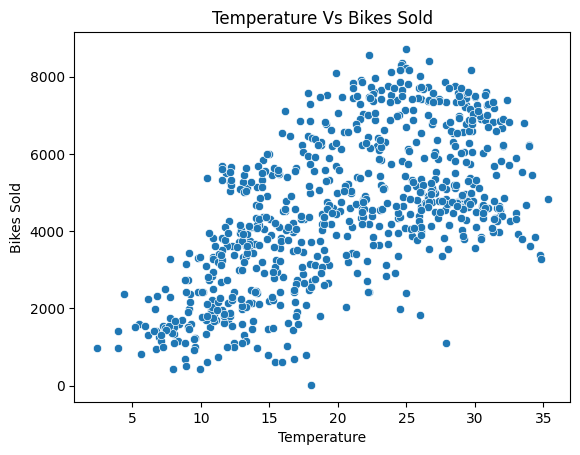

In [30]:
# As can be seen from this scatterplot with increase in temperature (till 35 degrees) count of bike rental increases

sns.scatterplot(
    bike_data,
    x = 'temp',
    y = 'cnt'
)
plt.xlabel('Temperature')
plt.ylabel('Bikes Sold')

plt.title('Temperature Vs Bikes Sold')
plt.show()

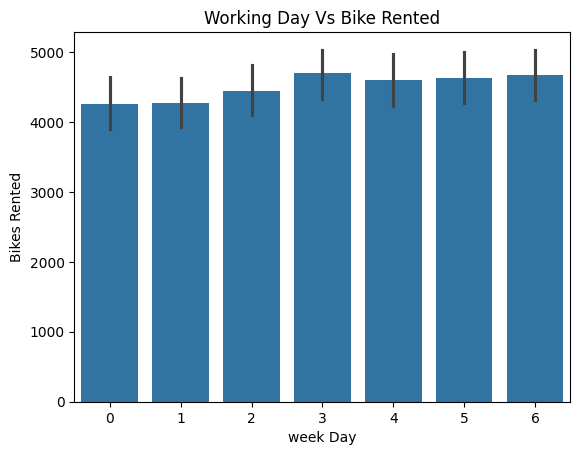

In [24]:
#As can be seen from this barplot, bike rented on each day of the week is quite similar

sns.barplot(
    bike_data,
    x = 'weekday',
    y = 'cnt'
)
plt.xlabel('week Day')
plt.ylabel('Bikes Rented')
plt.title('Working Day Vs Bike Rented')
plt.show()

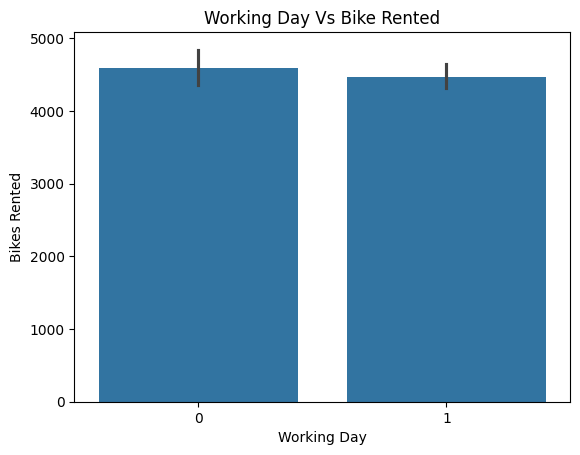

In [23]:
#As can be seen from this barplot, bike rented on working day or non working day is quite similar

sns.barplot(
    bike_data,
    x = 'workingday',
    y = 'cnt'
)
plt.xlabel('Working Day')
plt.ylabel('Bikes Rented')
plt.title('Working Day Vs Bike Rented')
plt.show()

In [26]:
bike_data['season'] = bike_data['season'].map({
    1:'spring',
    2:'summer',
    3:'fall',
    4:'winter'
})

bike_data['weathersit'] = bike_data['weathersit'].map({
    1:'clear',
    2:'mist',
    3:'light_rain',
    4:'heavy_rain'
})

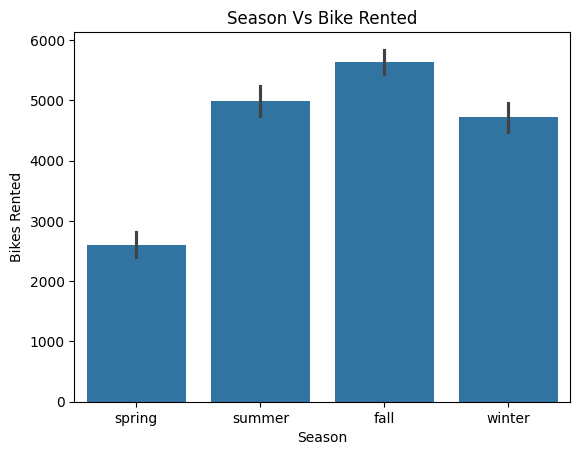

In [27]:
#As can be seen from this barplot, bike rented count goes down in the season of spring

sns.barplot(
    bike_data,
    x = 'season',
    y = 'cnt'
)
plt.xlabel('Season')
plt.ylabel('Bikes Rented')
plt.title('Season Vs Bike Rented')
plt.show()

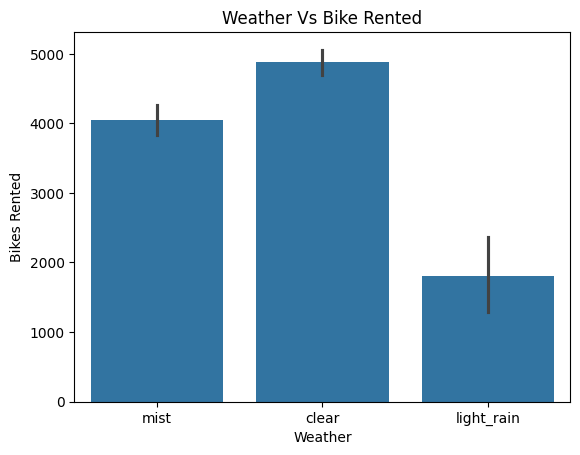

In [32]:
#As can be seen from this boxplot, bike rented on clear weather is the highest where in light rain is the lowest with on heavy rain it becomes 0
sns.barplot(
    bike_data,
    x = 'weathersit',
    y = 'cnt'
)
plt.xlabel('Weather')
plt.ylabel('Bikes Rented')
plt.title('Weather Vs Bike Rented')
plt.show()

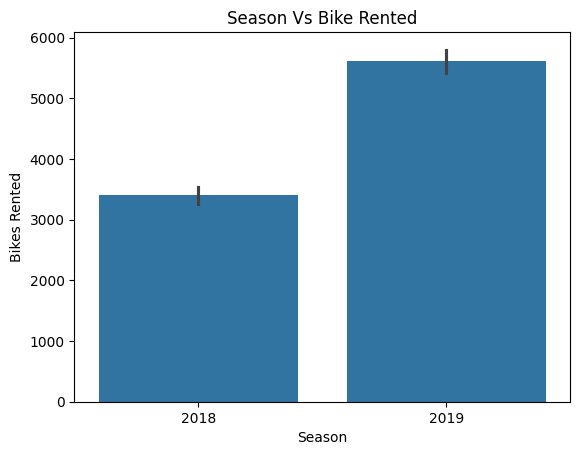

In [29]:
# As compare to year 2018, 2019 year has increase in count of bike rented
sns.barplot(
    bike_data,
    x = 'year',
    y = 'cnt'
)
plt.xlabel('Season')
plt.ylabel('Bikes Rented')
plt.title('Season Vs Bike Rented')
plt.show()

In [84]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   season      730 non-null    object 
 2   yr          730 non-null    int64  
 3   mnth        730 non-null    int64  
 4   holiday     730 non-null    int64  
 5   weekday     730 non-null    int32  
 6   workingday  730 non-null    int64  
 7   weathersit  730 non-null    object 
 8   temp        730 non-null    float64
 9   atemp       730 non-null    float64
 10  hum         730 non-null    float64
 11  windspeed   730 non-null    float64
 12  casual      730 non-null    int64  
 13  registered  730 non-null    int64  
 14  cnt         730 non-null    int64  
 15  year        730 non-null    int32  
 16  month       730 non-null    int32  
 17  day         730 non-null    int32  
dtypes: float64(4), int32(4), int64(8), object(2)
memory usage: 91.4+ KB


In [85]:
bike_data.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month,day
0,1,spring,0,1,0,0,1,mist,14.110847,18.18125,80.5833,10.749882,331,654,985,2018,1,1
1,2,spring,0,1,0,1,1,mist,14.902598,17.68695,69.6087,16.652113,131,670,801,2018,1,2
2,3,spring,0,1,0,2,1,clear,8.050924,9.47025,43.7273,16.636703,120,1229,1349,2018,1,3
3,4,spring,0,1,0,3,1,clear,8.200000,10.60610,59.0435,10.739832,108,1454,1562,2018,1,4
4,5,spring,0,1,0,4,1,clear,9.305237,11.46350,43.6957,12.522300,82,1518,1600,2018,1,5


In [86]:
## One hot encoding for season and wethersit columns

bike_data = pd.get_dummies(
    bike_data,
    columns=['season', 'weathersit'],
    drop_first=True
)

In [87]:
bike_data.head()

,instant,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,...,registered,cnt,year,month,day,season_spring,season_summer,season_winter,weathersit_light_rain,weathersit_mist
0,1,0,1,0,0,1,14.110847,18.18125,80.5833,10.749882,...,654,985,2018,1,1,True,False,False,False,True
1,2,0,1,0,1,1,14.902598,17.68695,69.6087,16.652113,...,670,801,2018,1,2,True,False,False,False,True
2,3,0,1,0,2,1,8.050924,9.47025,43.7273,16.636703,...,1229,1349,2018,1,3,True,False,False,False,False
3,4,0,1,0,3,1,8.200000,10.60610,59.0435,10.739832,...,1454,1562,2018,1,4,True,False,False,False,False
4,5,0,1,0,4,1,9.305237,11.46350,43.6957,12.522300,...,1518,1600,2018,1,5,True,False,False,False,False


In [88]:
bike_data.drop('instant', axis=1, inplace=True)

In [89]:
bike_data.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,year,month,day,season_spring,season_summer,season_winter,weathersit_light_rain,weathersit_mist
0,0,1,0,0,1,14.110847,18.18125,80.5833,10.749882,331,654,985,2018,1,1,True,False,False,False,True
1,0,1,0,1,1,14.902598,17.68695,69.6087,16.652113,131,670,801,2018,1,2,True,False,False,False,True
2,0,1,0,2,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349,2018,1,3,True,False,False,False,False
3,0,1,0,3,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562,2018,1,4,True,False,False,False,False
4,0,1,0,4,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600,2018,1,5,True,False,False,False,False


In [90]:
corr = bike_data.corr(numeric_only=True)

corr['cnt'].sort_values(ascending=False)

,cnt
cnt,1.000000
registered,0.945411
casual,0.672123
atemp,0.630685
temp,0.627044
year,0.569728
yr,0.569728
mnth,0.278191
month,0.278191
season_summer,0.145325


In [91]:
bike_data.drop(['month','year'], axis = 1, inplace=True)

In [92]:
bike_data.drop(['casual','registered'], axis = 1, inplace = True)

In [93]:
bike_data.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,cnt,day,season_spring,season_summer,season_winter,weathersit_light_rain,weathersit_mist
0,0,1,0,0,1,14.110847,18.18125,80.5833,10.749882,985,1,True,False,False,False,True
1,0,1,0,1,1,14.902598,17.68695,69.6087,16.652113,801,2,True,False,False,False,True
2,0,1,0,2,1,8.050924,9.47025,43.7273,16.636703,1349,3,True,False,False,False,False
3,0,1,0,3,1,8.200000,10.60610,59.0435,10.739832,1562,4,True,False,False,False,False
4,0,1,0,4,1,9.305237,11.46350,43.6957,12.522300,1600,5,True,False,False,False,False


In [94]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     730 non-null    int64  
 1   mnth                   730 non-null    int64  
 2   holiday                730 non-null    int64  
 3   weekday                730 non-null    int32  
 4   workingday             730 non-null    int64  
 5   temp                   730 non-null    float64
 6   atemp                  730 non-null    float64
 7   hum                    730 non-null    float64
 8   windspeed              730 non-null    float64
 9   cnt                    730 non-null    int64  
 10  day                    730 non-null    int32  
 11  season_spring          730 non-null    bool   
 12  season_summer          730 non-null    bool   
 13  season_winter          730 non-null    bool   
 14  weathersit_light_rain  730 non-null    bool   
 15  weathe

In [95]:
bike_data[['season_spring','season_summer','season_winter','weathersit_light_rain', 'weathersit_mist']] = bike_data[['season_spring','season_summer','season_winter','weathersit_light_rain', 'weathersit_mist']].astype(int)

In [96]:
bike_data.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,cnt,day,season_spring,season_summer,season_winter,weathersit_light_rain,weathersit_mist
0,0,1,0,0,1,14.110847,18.18125,80.5833,10.749882,985,1,1,0,0,0,1
1,0,1,0,1,1,14.902598,17.68695,69.6087,16.652113,801,2,1,0,0,0,1
2,0,1,0,2,1,8.050924,9.47025,43.7273,16.636703,1349,3,1,0,0,0,0
3,0,1,0,3,1,8.200000,10.60610,59.0435,10.739832,1562,4,1,0,0,0,0
4,0,1,0,4,1,9.305237,11.46350,43.6957,12.522300,1600,5,1,0,0,0,0


In [97]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     730 non-null    int64  
 1   mnth                   730 non-null    int64  
 2   holiday                730 non-null    int64  
 3   weekday                730 non-null    int32  
 4   workingday             730 non-null    int64  
 5   temp                   730 non-null    float64
 6   atemp                  730 non-null    float64
 7   hum                    730 non-null    float64
 8   windspeed              730 non-null    float64
 9   cnt                    730 non-null    int64  
 10  day                    730 non-null    int32  
 11  season_spring          730 non-null    int64  
 12  season_summer          730 non-null    int64  
 13  season_winter          730 non-null    int64  
 14  weathersit_light_rain  730 non-null    int64  
 15  weathe

In [98]:
### train test split

from sklearn.model_selection import train_test_split

bike_data_train, bike_data_test = train_test_split (bike_data, train_size = 0.8, random_state = 101)
bike_data_train.shape
bike_data_test.shape

(146, 16)

In [99]:
bike_data_train.shape

(584, 16)

In [100]:
bike_data_train.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,cnt,day,season_spring,season_summer,season_winter,weathersit_light_rain,weathersit_mist
23,0,1,0,2,1,3.993043,5.89650,49.1739,10.608110,1416,24,1,0,0,0,0
527,1,6,0,2,1,26.786653,29.89375,83.3333,14.374582,4972,12,0,1,0,0,1
257,0,9,0,5,0,23.677500,27.68355,70.9167,18.166782,3659,15,0,0,0,0,1
18,0,1,0,4,1,11.979134,14.92110,74.1739,13.957239,1650,19,1,0,0,0,1
148,0,5,0,1,1,27.367500,30.77750,81.8750,14.333846,4788,29,0,1,0,0,0


In [101]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical = ['yr','mnth','weekday','temp','atemp','hum','windspeed','cnt','day']
bike_data_train[numerical] = scaler.fit_transform(bike_data_train[numerical])
bike_data_train.describe()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,cnt,day,season_spring,season_summer,season_winter,weathersit_light_rain,weathersit_mist
count,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000
mean,0.503425,0.491905,0.027397,0.498002,0.693493,0.543924,0.519935,0.559569,0.340796,0.524580,0.483790,0.251712,0.255137,0.232877,0.027397,0.328767
std,0.500417,0.312464,0.163378,0.332683,0.461438,0.229266,0.214463,0.180387,0.160739,0.225580,0.291412,0.434369,0.436312,0.423027,0.163378,0.470168
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.181818,0.000000,0.166667,0.000000,0.346603,0.340377,0.423832,0.226924,0.373784,0.233333,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.454545,0.000000,0.500000,1.000000,0.540519,0.525578,0.558573,0.315395,0.530470,0.466667,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.727273,0.000000,0.833333,1.000000,0.744819,0.698392,0.691294,0.430268,0.688562,0.733333,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

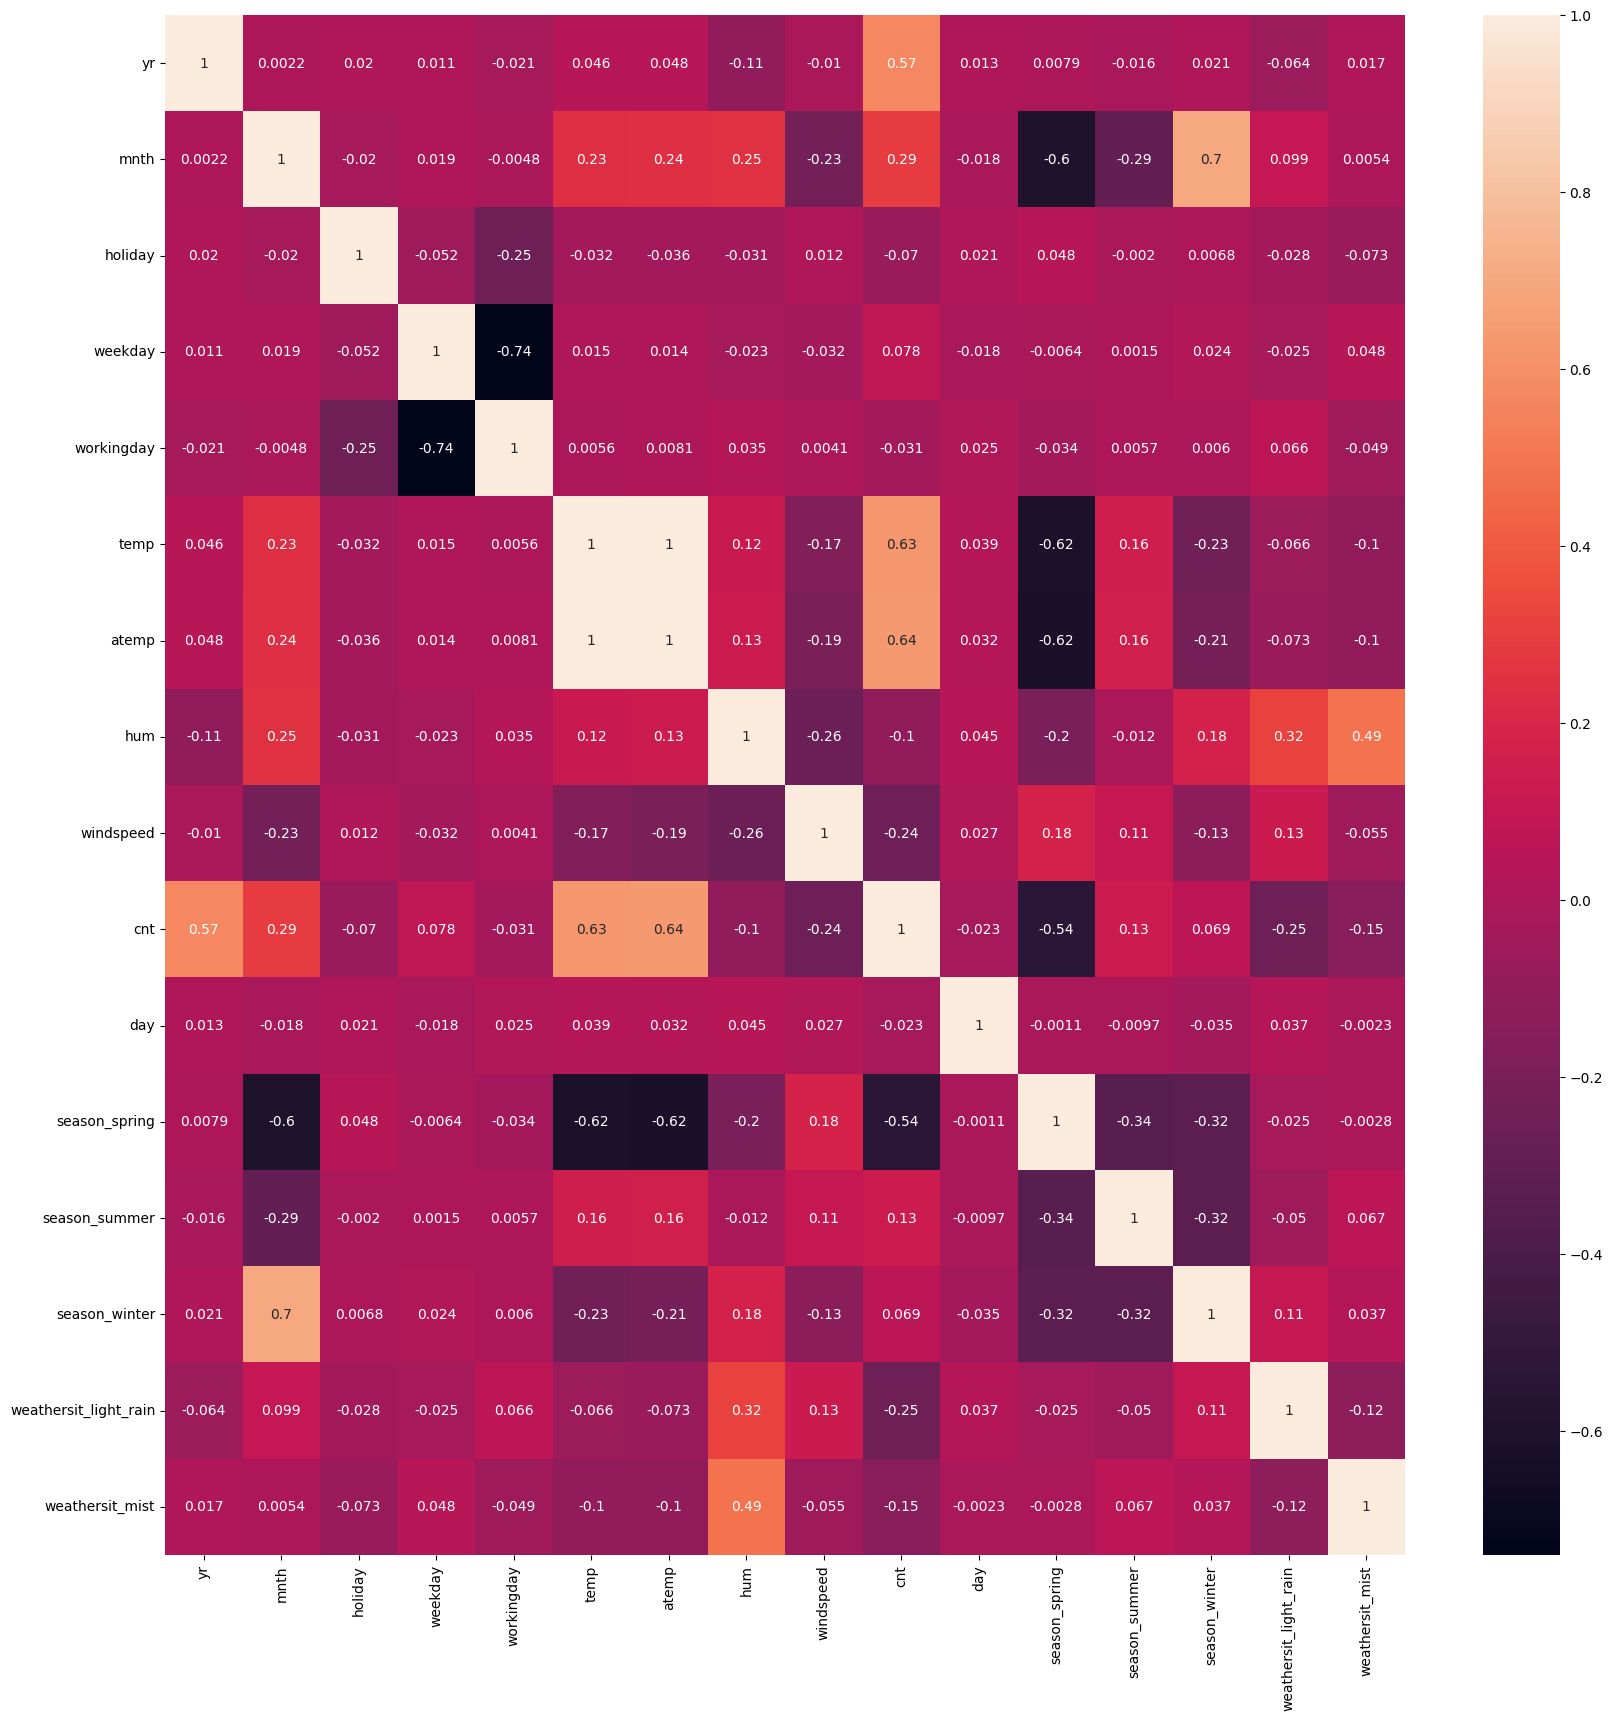

In [102]:
### heatmaps to check correlation, multi collinearity

plt.figure(figsize = (20,20))
sns.heatmap(bike_data_train.corr(), annot = True)

In [103]:
y_train = bike_data_train.pop('cnt')
x_train = bike_data_train

In [104]:
y_train.head()

,cnt
23,0.163366
527,0.580101
257,0.426228
18,0.190789
148,0.558537


In [105]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 23 to 523
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     584 non-null    float64
 1   mnth                   584 non-null    float64
 2   holiday                584 non-null    int64  
 3   weekday                584 non-null    float64
 4   workingday             584 non-null    int64  
 5   temp                   584 non-null    float64
 6   atemp                  584 non-null    float64
 7   hum                    584 non-null    float64
 8   windspeed              584 non-null    float64
 9   day                    584 non-null    float64
 10  season_spring          584 non-null    int64  
 11  season_summer          584 non-null    int64  
 12  season_winter          584 non-null    int64  
 13  weathersit_light_rain  584 non-null    int64  
 14  weathersit_mist        584 non-null    int64  
dtypes: float64

In [106]:
import statsmodels.api as sm

In [107]:
x_train.reset_index(drop = True)
y_train.reset_index(drop = True)

x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 23 to 523
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     584 non-null    float64
 1   mnth                   584 non-null    float64
 2   holiday                584 non-null    int64  
 3   weekday                584 non-null    float64
 4   workingday             584 non-null    int64  
 5   temp                   584 non-null    float64
 6   atemp                  584 non-null    float64
 7   hum                    584 non-null    float64
 8   windspeed              584 non-null    float64
 9   day                    584 non-null    float64
 10  season_spring          584 non-null    int64  
 11  season_summer          584 non-null    int64  
 12  season_winter          584 non-null    int64  
 13  weathersit_light_rain  584 non-null    int64  
 14  weathersit_mist        584 non-null    int64  
dtypes: float64

In [108]:
x_train = sm.add_constant(x_train)

In [109]:
x_train.head()

,const,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,day,season_spring,season_summer,season_winter,weathersit_light_rain,weathersit_mist
23,1.0,0.0,0.000000,0,0.333333,1,0.047675,0.051010,0.388271,0.280244,0.766667,1,0,0,0,0
527,1.0,1.0,0.454545,0,0.333333,1,0.740406,0.681002,0.824813,0.396136,0.366667,0,1,0,0,1
257,1.0,0.0,0.727273,0,0.833333,0,0.645914,0.622978,0.666134,0.512820,0.466667,0,0,0,0,1
18,1.0,0.0,0.000000,0,0.666667,1,0.290384,0.287930,0.707760,0.383295,0.600000,1,0,0,0,1
148,1.0,0.0,0.363636,0,0.166667,1,0.758058,0.704203,0.806176,0.394883,0.933333,0,1,0,0,0


In [110]:
lr = sm.OLS(y_train, x_train).fit()

In [111]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     181.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          5.63e-205
Time:                        16:46:49   Log-Likelihood:                 553.84
No. Observations:                 584   AIC:                            -1076.
Df Residuals:                     568   BIC:                            -1006.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.27

In [112]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = x_train.columns
vif['VIF'] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
6,temp,201.06
7,atemp,195.92
0,const,101.14
11,season_spring,5.91
2,mnth,3.98
13,season_winter,3.76
5,workingday,2.76
12,season_summer,2.62
4,weekday,2.58
8,hum,2.12


In [113]:
x_train.drop('atemp', axis = 1, inplace = True)

In [114]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = x_train.columns
vif['VIF'] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,100.99
10,season_spring,5.86
2,mnth,3.97
12,season_winter,3.55
6,temp,3.43
5,workingday,2.76
4,weekday,2.58
11,season_summer,2.52
7,hum,2.06
14,weathersit_mist,1.66


In [123]:
lr = sm.OLS(y_train, x_train).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     194.0
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          5.83e-206
Time:                        16:58:39   Log-Likelihood:                 553.45
No. Observations:                 584   AIC:                            -1077.
Df Residuals:                     569   BIC:                            -1011.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.27

In [125]:
y_train_pred  = lr.predict(x_train)

<Axes: ylabel='Density'>

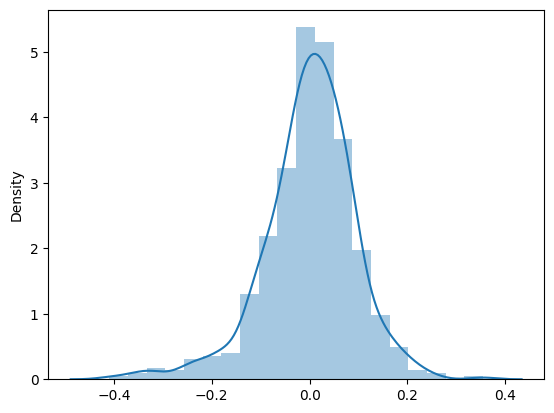

In [126]:
sns.distplot((y_train - y_train_pred), bins = 20)

In [127]:
bike_data_test[numerical] = scaler.transform(bike_data_test[numerical])
bike_data_test.describe()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,cnt,day,season_spring,season_summer,season_winter,weathersit_light_rain,weathersit_mist
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,0.486301,0.544209,0.034247,0.502283,0.678082,0.543564,0.515712,0.571530,0.369657,0.530303,0.518265,0.226027,0.239726,0.287671,0.034247,0.369863
std,0.501533,0.316000,0.182488,0.339589,0.468820,0.224358,0.212676,0.188405,0.154753,0.232768,0.300704,0.419697,0.428386,0.454235,0.182488,0.484429
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.113228,0.061963,-0.240150,0.063540,0.068323,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.272727,0.000000,0.166667,0.000000,0.340373,0.322762,0.427449,0.259925,0.357084,0.266667,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.545455,0.000000,0.500000,1.000000,0.574786,0.556655,0.569222,0.357688,0.528360,0.533333,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.818182,0.000000,0.833333,1.000000,0.732099,0.676233,0.698806,0.453806,0.725653,0.766667,0.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.970925,0.980934,1.002662,0.751290,1.018634,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [128]:
y_test = bike_data_test.pop('cnt')
x_test = bike_data_test

In [129]:
x_test.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,day,season_spring,season_summer,season_winter,weathersit_light_rain,weathersit_mist
299,0.0,0.818182,0,0.833333,0,0.511964,0.496145,0.798722,0.361537,0.866667,0,0,1,0,1
723,1.0,1.000000,1,0.333333,0,0.289300,0.282736,0.698870,0.301676,0.800000,1,0,0,0,1
647,1.0,0.818182,0,0.500000,1,0.566998,0.556652,0.566027,0.341041,0.300000,0,0,1,0,0
520,1.0,0.454545,0,0.333333,1,0.600225,0.586515,0.543663,0.385888,0.133333,0,1,0,0,1
114,0.0,0.272727,0,0.333333,1,0.682257,0.650319,0.752396,0.335912,0.800000,0,1,0,0,0


In [130]:
x_test.drop('atemp',axis = 1, inplace = True)

In [131]:
x_test = sm.add_constant(x_test)

In [132]:
y_test_pred = lr.predict(x_test)

<Axes: ylabel='Density'>

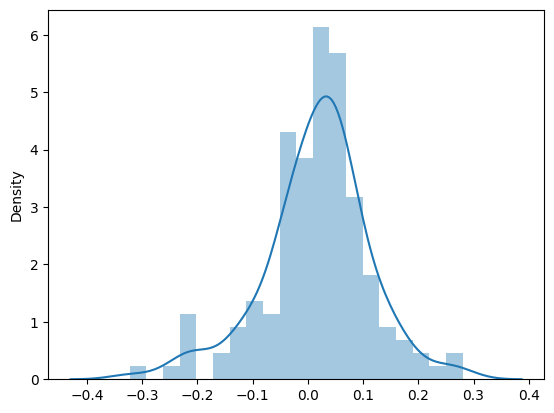

In [133]:
sns.distplot((y_test - y_test_pred), bins = 20)

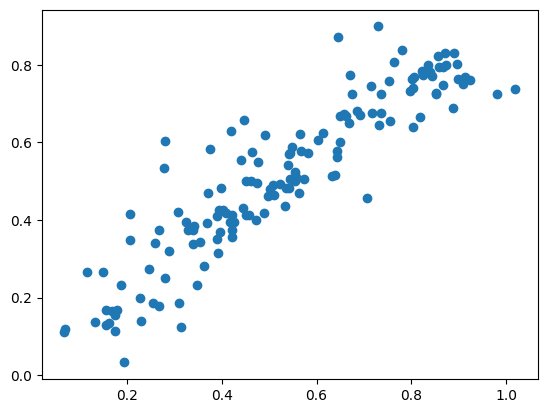

In [134]:
plt.scatter(y_test, y_test_pred)
